In [1]:
# 오토인코더 기반 이상탐지 모델

# 1. 라이브러리 추출
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from sklearn.model_selection import train_test_split
from tensorflow.keras import layers, models
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score
import os
from matplotlib import font_manager
from sklearn.metrics import roc_auc_score, roc_curve

np.random.seed(42)
tf.random.set_seed(42)

I0000 00:00:1787547774.156361   91775 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1787547774.157189   91775 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1787547774.324552   91775 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1787547775.990349   91775 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_E

In [2]:
# 2. 가상 센서 데이터 생성
n_normal = 5000 # 정상 데이터 샘플 수
n_anomaly = 500 # 불량 데이터 샘플 수
n_features = 4  # 센서 개수

# 정상 데이터 : 평균 0, 표준편차 1인 정규분포내에서 값을 샘플링하여 센서 데이터 생성
normal_data = np.random.normal(loc=0.0, scale=1.0, size=(n_normal, n_features))

# 이상 데이터 : 평균을 크게 이동시키고, 분산을 키워서 비정상적인 패턴의 센서 데이터 생성
anomaly_data = np.random.normal(loc=3.0, scale=1.5, size=(n_anomaly, n_features))

X = np.vstack([normal_data, anomaly_data])      # X에 정상과 이상 데이터를 위아래로 이어 붙임
y = np.hstack([np.zeros(n_normal), np.ones(n_anomaly)])     # 정상은 0, 이상은 1로 레이블 벡터를 만듬


In [3]:
anomaly_data

array([[3.52242937e+00, 3.42498539e+00, 1.59522023e+00, 3.86937633e+00],
       [7.64875987e-01, 2.01872351e+00, 1.36828065e-03, 5.33793978e+00],
       [2.65267576e+00, 6.25032605e+00, 4.20442489e+00, 3.67214732e+00],
       ...,
       [5.78462328e+00, 4.14047897e+00, 2.12222122e+00, 3.58840879e+00],
       [3.93936640e+00, 1.50792409e+00, 2.57260377e+00, 4.65058774e+00],
       [2.64760897e-01, 1.12435718e+00, 2.73538942e+00, 3.53051939e+00]],
      shape=(500, 4))

In [4]:
normal_data

array([[ 0.49671415, -0.1382643 ,  0.64768854,  1.52302986],
       [-0.23415337, -0.23413696,  1.57921282,  0.76743473],
       [-0.46947439,  0.54256004, -0.46341769, -0.46572975],
       ...,
       [ 2.03658236, -0.41274409,  1.23286679, -0.46866051],
       [ 0.88883882,  0.90249166,  0.95259051,  0.38782734],
       [ 1.37736658,  0.37835397,  1.71352973, -1.6199198 ]],
      shape=(5000, 4))

In [5]:
# 3. 학습/테스트 데이터 분리(70%/30%)

X_train, X_test, y_train, y_test = train_test_split(
  X, y, test_size=0.3, random_state=42, stratify=y
)

# 이상한지 autoencoder는 정상 데이터로만 학습하므로 정상 샘플만 필터링
X_train_normal = X_train[y_train == 0]        # 레이블이 0(정상)인 데이터만 x 데이터로 필터링

In [6]:
# 4. 데이터 스케일링 (표준화)
scaler = StandardScaler()       # 평균 0, 분산 1로 맞추는 표준화 객체 생성
scaler.fit(X_train_normal)      # 정상 학습 데이터로 표준화 기준 적용

X_train_normal_scaled = scaler.transform(X_train_normal)        # 학습용 정상 데이터 표준화
X_test_scaled = scaler.transform(X_test)

In [7]:
# 5. Autoencoder 모델 정의
input_dim = n_features                      # 입력 차원은 센서 개수와 동일하게 설정
encoding_dim = 2                            # 잠재공간(latent space) 2차원으로 설정해서 압축을 진행

# 입력 레이어 정의, 입력 크기는 센서 개수와 동일하게 설정
input_layer = layers.Input(shape=(input_dim,), name='input')

# 인코더 부분 : 입력을 더 작은 차원(2차원)으로 압축하는 레이어
# 8개의 뉴런으로 첫번째 레이어 생성
encoded = layers.Dense(8, activation='relu', name='encoder_dense1')(input_layer)
# 2차원 잠재 표현으로 압축
encoded = layers.Dense(encoding_dim, activation='relu', name='encoder_dense2')(encoded)

# 디코더 : 압축된 표현을 다시 원래 차원으로 복원하는 레이어
# 8개의 뉴런으로 복원을 하는 중간 레이어 구성
decoded = layers.Dense(8, activation='relu', name='decoder_dense1')(encoded)
# 원래 입력 차원으로 복원하여 출력
decoded = layers.Dense(input_dim, activation='linear', name='decoder_output')(decoded)

# 입력부터 출력까지를 연결해주는 autoencoder 모델 구성
autoencoder = models.Model(inputs=input_layer, outputs=decoded, name='autoencoder_model')

# 모델 구조 출력
autoencoder.summary()


E0000 00:00:1787547776.688984   91775 cuda_executor.cc:1737] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1787547776.723926   91775 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


Model: "autoencoder_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 4)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_dense1 (Dense)          │ (None, 8)              │            40 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_dense2 (Dense)          │ (None, 2)              │            18 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_dense1 (Dense)          │ (None, 8)              │            24 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_output (Dense)          │ (None, 4)              │            36 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 118 (472.00 B)

 Trainable params: 118 (472.00 B)

 Non-trainable params: 0 (0.00 B)

In [8]:
# 6. Autoencoder 모델 컴파일 설정

autoencoder.compile(
  optimizer='adam',             # 최적화 알고리즘은 adam 사용
  loss='mse'                    # 입력과 복원된 출력의 차이를 제곱오차로 계산
)

# 이상탐지의 경우 재구성 오차를 줄이는 방향으로 학습함

In [9]:
# 7. Autoencoder 학습

# 정상 데이터만 사용해서 학습 수행
history = autoencoder.fit(
  X_train_normal_scaled,    # 입력 데이터
  X_train_normal_scaled,    # 출력 비교 데이터
  epochs=70,                # 훈련 횟수
  batch_size=64,            # 1회 훈련에서 1회 훈련에 사용되는 데이터 개수
  validation_split=0.2,     # 검증데이터 % 설정
  verbose=1                 # 학습 진행상황 출력 옵션
)

Epoch 1/70
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.9380 - val_loss: 0.8496
Epoch 2/70
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.8332 - val_loss: 0.7978
Epoch 3/70
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.7871 - val_loss: 0.7524
Epoch 4/70
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.7416 - val_loss: 0.7094
Epoch 5/70
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.7021 - val_loss: 0.6785
Epoch 6/70
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.6752 - val_loss: 0.6605
Epoch 7/70
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.6565 - val_loss: 0.6465
Epoch 8/70
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.6401 - val_loss: 0.6326
Epoch 9/70
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.6244 - val_loss: 0.6189
Epoch 10/70
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.6085 - val_loss: 0.6060
Epoch 11/70
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.5934 - val_loss: 0.5944
Epoch 12/70
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.5801 - val_lo

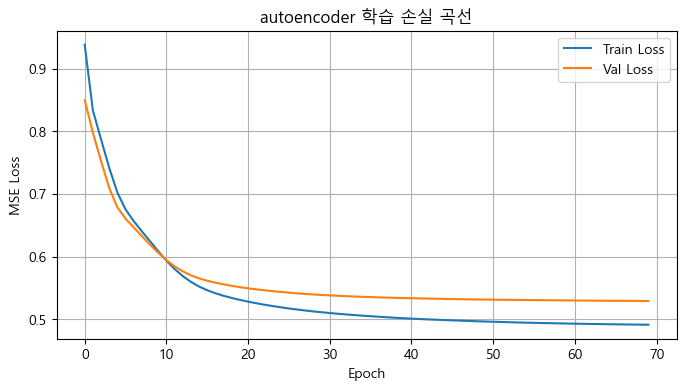

In [15]:
#==========================================================
# 8. 학습과정 시각화 (loss) 
#==========================================================

# WSL에서 Windows의 맑은 고딕 폰트 사용
font_path = "/mnt/c/Windows/Fonts/malgun.ttf"

if not os.path.exists(font_path):
    raise FileNotFoundError(f"폰트 파일을 찾을 수 없습니다: {font_path}")

# Matplotlib에 폰트 파일 등록
font_manager.fontManager.addfont(font_path)

# 등록된 폰트 이름으로 설정
font_name = font_manager.FontProperties(fname=font_path).get_name()
plt.rcParams["font.family"] = font_name
plt.rcParams["axes.unicode_minus"] = False

plt.figure(figsize=(8,4))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('autoencoder 학습 손실 곡선')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.grid(True)
plt.show()

In [11]:
# 9. 테스트 데이터에서 재구성 오차 계산

# 테스트 데이터를 autoencoder 모델에 통과 시켜서 복원값을 얻어옴
X_test_pred = autoencoder.predict(X_test_scaled)
reconstruction_error = np.mean(np.square(X_test_scaled - X_test_pred), axis=1)

# 각 샘플에 대해서 (입력 - 복원값)^2 를 계산하고, 특징 차원 방향으로 평균을 내서 재구성 오차를 구함


52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


In [12]:
# 10. 이상 탐지 임계값(threshold)설정

X_train_pred = autoencoder.predict(X_train_normal_scaled)
train_reconstruction_error = np.mean(
  np.square(X_train_normal_scaled - X_train_pred), axis = 1
)

# 정상 오차의 95%값을 임계값으로 설정
threshold = np.percentile(train_reconstruction_error, 95)
print('이상 감지 임계값(95%) : ', threshold)

110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 741us/step
이상 감지 임계값(95%) :  1.4984771309312606


findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.


재구성 오차 기반 ROC-AUC :  0.9898222222222223


findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
/home/pc/anaconda3/envs/ai/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 51060 (\N{HANGUL SYLLABLE I}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/pc/anaconda3/envs/ai/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 49345 (\N{HANGUL SYLLABLE SANG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/pc/anaconda3/envs/ai/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 53456 (\N{HANGUL SYLLABLE TAM}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/pc/anaconda3/envs/ai/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 51648 (\N{HANGUL SYLLABLE JI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, *

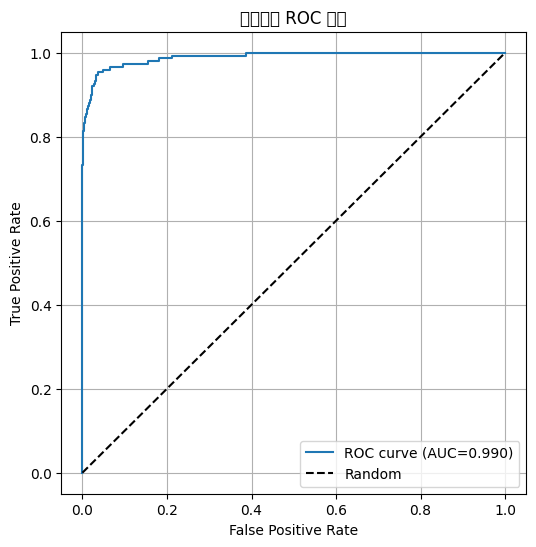

In [13]:
# 11. 이상 여부 예측 및 ROC-AUC 평가

# 재구성 오차가 임계값보다 크면 이상(1), 작으면 정상(0)으로 예측 레이블을 만듬
y_pred_anomaly = (reconstruction_error > threshold).astype(int)

# 재구성 오차를 정수로 사용하여 ROC-AUC를 계산해서 이상탐지 성능 측정
auc = roc_auc_score(y_test, reconstruction_error)
print("재구성 오차 기반 ROC-AUC : ", auc)

fpr, tpr, _ = roc_curve(y_test, reconstruction_error)     # roc 곡선을 그리기위해 FPR, TPR 값을 계산

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f'ROC curve (AUC={auc:.3f})')     # FPR-TPR 곡선을 그리고 AUC를 표시
plt.plot([0,1], [0,1], 'k--', label='Random')              # 무작위 분류 기준선(대각선)을 점선으로 그리기
plt.xlabel('False Positive Rate')                          # X축 라벨을 가성률로 설정
plt.ylabel('True Positive Rate')                           # Y축 라벨을 진성률로 설정
plt.title('이상탐지 ROC 곡선')      
plt.legend()
plt.grid(True)
plt.show()

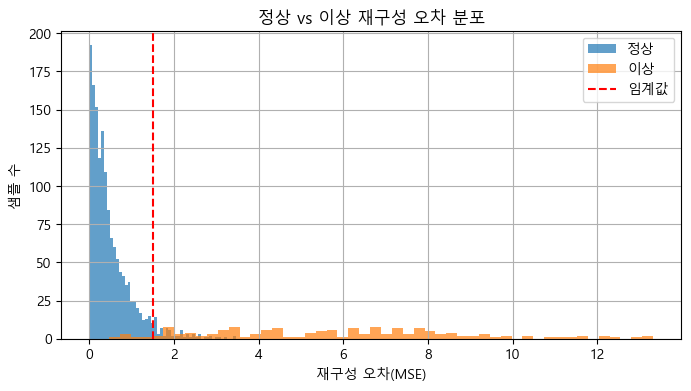

In [16]:
# 12. 재구성 오차 분포 시각화

plt.figure(figsize=(8,4))
plt.hist(reconstruction_error[y_test == 0], bins=50, alpha=0.7, label="정상") # 정상 샘플 오차 분포 그리기
plt.hist(reconstruction_error[y_test == 1], bins=50, alpha=0.7, label="이상") # 이상 샘플 오차 분포 그리기
plt.axvline(threshold, color='red', linestyle="--", label="임계값")           #  threshold 선 그리기
plt.title('정상 vs 이상 재구성 오차 분포')
plt.xlabel('재구성 오차(MSE)')
plt.ylabel('샘플 수')
plt.legend()
plt.grid(True)
plt.show()